In [21]:
#We will test the BAO data loading
import sys
sys.path.append('../src')

from bao_data import load_desi_bao, get_bao_dv_only
#Loading the data
dv_data, dm_data, dh_data = load_desi_bao()

print("DESI DR2 BAO DATA (from official files)")
print("="* 39)

print("\nDV/rs measurements (Volume distance):")
print("z\tDV/rs\t\t\u03C3")
for row in dv_data:
    print(f"{row[0]:.3f}\t{row[1]:.3f}\t\t{row[2]:.3f}")

print("\nDM/rs measurements (Comoving distance):")
print("z\tDM/rs\t\t\u03C3")
for row in dm_data:
    print(f"{row[0]:.3f}\t{row[1]:.3f}\t\t{row[2]:.3f}")

print("\nDH/rs measurements (Hubble distance):")
print("z\tDH/rs\t\t\u03C3")
for row in dh_data:
    print(f"{row[0]:.3f}\t{row[1]:.3f}\t\t{row[2]:.3f}")

print(f"\nTotal measurements: {len(dv_data) + len(dm_data) + len(dh_data)}")

DESI DR2 BAO DATA (from official files)

DV/rs measurements (Volume distance):
z	DV/rs		σ
0.295	7.942		0.076

DM/rs measurements (Comoving distance):
z	DM/rs		σ
0.510	13.588		0.168
0.706	17.351		0.180
0.934	21.576		0.162
1.321	27.601		0.325
1.484	30.512		0.764
2.330	38.989		0.532

DH/rs measurements (Hubble distance):
z	DH/rs		σ
0.510	21.863		0.429
0.706	19.455		0.334
0.934	17.641		0.201
1.321	14.176		0.225
1.484	12.817		0.518
2.330	8.632		0.101

Total measurements: 13


Loading data...
  OHD: 43 points
  Pantheon: 1048 supernovae
  DESI BAO: 13 measurements (DV: 1, DM: 6, DH: 6)

Running MCMC (OHD + Pantheon + DESI BAO)...


100%|████████████████████████████████████| 5000/5000 [1:40:21<00:00,  1.20s/it]



FINAL RESULTS: OHD + Pantheon + DESI BAO
q₀ = -0.595 ± 0.013
q₁ = 0.766 ± 0.021
M_B = -19.362 ± 0.005

Comparison with previous (OHD+Pantheon only):
  Without BAO: q₀ = -0.568 ± 0.028, q₁ = 0.697 ± 0.048
  With BAO:    q₀ = -0.595 ± 0.013, q₁ = 0.766 ± 0.021


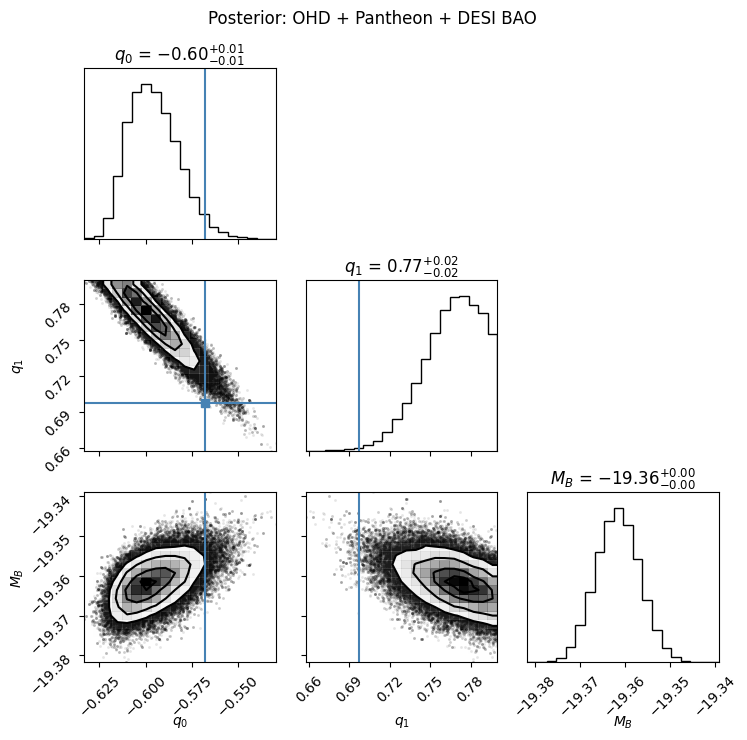

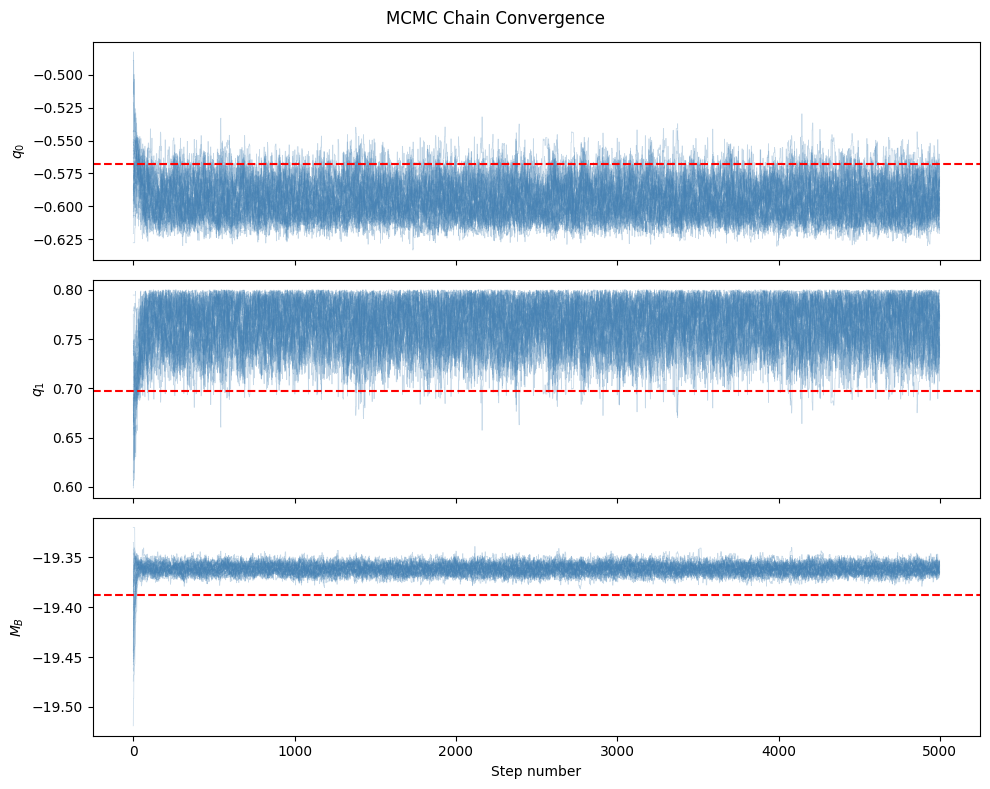


Done.


In [50]:
import numpy as np
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.integrate import quad

# -----------------------------------------------------------------------------
# 1. Cosmological functions (from the paper)
# -----------------------------------------------------------------------------

def hubble_z(z, q0, q1, H0=70):
    """H(z) from Eq. 22: H0*(1+z)^(1+q0)*(1+z^2)^(q1/2)"""
    return H0 * (1 + z)**(1 + q0) * (1 + z**2)**(q1 / 2)

def comoving_distance(z, q0, q1, H0=70):
    """Comoving distance DC(z) = ∫_0^z c/H(z') dz' in Mpc"""
    c = 299792.458  # km/s
    if np.isscalar(z):
        def integrand(zp):
            return c / hubble_z(zp, q0, q1, H0)
        res, _ = quad(integrand, 0, z)
        return res
    else:
        res = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp):
                return c / hubble_z(zp, q0, q1, H0)
            res[i], _ = quad(integrand, 0, zi)
        return res

def luminosity_distance(z, q0, q1, H0=70):
    """dL(z) = c(1+z) ∫_0^z dz'/H(z')"""
    c = 299792.458
    if np.isscalar(z):
        def integrand(zp):
            return 1.0 / hubble_z(zp, q0, q1, H0)
        integral, _ = quad(integrand, 0, z)
        return c * (1 + z) * integral
    else:
        dL = np.zeros_like(z)
        for i, zi in enumerate(z):
            def integrand(zp):
                return 1.0 / hubble_z(zp, q0, q1, H0)
            integral, _ = quad(integrand, 0, zi)
            dL[i] = c * (1 + zi) * integral
        return dL

def distance_modulus_theory(z, q0, q1, H0=70):
    """μ(z) = 5 log10(dL/1Mpc) + 25"""
    dL = luminosity_distance(z, q0, q1, H0)
    return 5 * np.log10(dL) + 25

# -----------------------------------------------------------------------------
# 2. Loading data
# -----------------------------------------------------------------------------

print("Loading data...")

# OHD
ohd = np.loadtxt(r'C:\Users\mriga\Downloads\OHD.txt')
z_ohd, H_ohd, H_err = ohd[:,0], ohd[:,1], ohd[:,2]
print(f"  OHD: {len(z_ohd)} points")

# Pantheon
sn = np.loadtxt(r'C:\Users\mriga\Downloads\Pantheon_1048.txt')
z_sn, mb, dmb = sn[:,0], sn[:,3], sn[:,4]
print(f"  Pantheon: {len(z_sn)} supernovae")

# DESI BAO – load mean and covariance files
mean_file = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_mean.txt'
cov_file  = r'C:\Users\mriga\Downloads\desi_gaussian_bao_ALL_GCcomb_cov.txt'
mean_data = np.loadtxt(mean_file, skiprows=1, dtype=str)
cov = np.loadtxt(cov_file)

dv_data, dm_data, dh_data = [], [], []
for i, row in enumerate(mean_data):
    z = float(row[0])
    val = float(row[1])
    qty = row[2]
    err = np.sqrt(cov[i,i])
    if 'DV_over_rs' in qty:
        dv_data.append([z, val, err])
    elif 'DM_over_rs' in qty:
        dm_data.append([z, val, err])
    elif 'DH_over_rs' in qty:
        dh_data.append([z, val, err])
dv_data = np.array(dv_data)
dm_data = np.array(dm_data)
dh_data = np.array(dh_data)
print(f"  DESI BAO: {len(dv_data)+len(dm_data)+len(dh_data)} measurements (DV: {len(dv_data)}, DM: {len(dm_data)}, DH: {len(dh_data)})")

# -----------------------------------------------------------------------------
# 3. Log-posterior function (OHD + Pantheon + BAO)
# -----------------------------------------------------------------------------

C_LIGHT = 299792.458  # km/s

def log_posterior(params, z_ohd, H_ohd, H_err, z_sn, mb, dmb,
                  dm_data, dh_data, dv_data, H0=70, rs=147.5):
    q0, q1, M_B = params

    # Prior
    if not (-0.8 < q0 < -0.4 and 0.5 < q1 < 0.8 and -20 < M_B < -18):
        return -np.inf

    # OHD likelihood
    H_model = H0 * (1 + z_ohd)**(1 + q0) * (1 + z_ohd**2)**(q1/2)
    chi2_ohd = np.sum(((H_ohd - H_model) / H_err)**2)

    # Pantheon likelihood
    mu_th = distance_modulus_theory(z_sn, q0, q1, H0)
    chi2_sn = np.sum(((mb - M_B - mu_th) / dmb)**2)

    # BAO likelihood
    chi2_bao = 0.0
    for z, obs, err in dm_data:
        DC = comoving_distance(z, q0, q1, H0)
        model = DC / rs
        chi2_bao += ((obs - model) / err)**2
    for z, obs, err in dh_data:
        H_val = hubble_z(z, q0, q1, H0)
        model = (C_LIGHT / H_val) / rs
        chi2_bao += ((obs - model) / err)**2
    for z, obs, err in dv_data:
        DC = comoving_distance(z, q0, q1, H0)
        DA = DC / (1 + z)
        H_val = hubble_z(z, q0, q1, H0)
        DV = ((1 + z)**2 * DA**2 * C_LIGHT * z / H_val) ** (1/3)
        model = DV / rs
        chi2_bao += ((obs - model) / err)**2

    total_chi2 = chi2_ohd + chi2_sn + chi2_bao
    return -0.5 * total_chi2

# -----------------------------------------------------------------------------
# 4. MCMC setup and run
# -----------------------------------------------------------------------------

n_walkers = 32
n_dim = 3
n_steps = 5000
n_burn = 500
H0 = 70
rs = 147.5

# Starting guess from previous OHD+Pantheon result
start_guess = np.array([-0.568, 0.697, -19.388])
np.random.seed(42)
start_positions = start_guess + 0.05 * np.random.randn(n_walkers, n_dim)

print("\nRunning MCMC (OHD + Pantheon + DESI BAO)...")
sampler = emcee.EnsembleSampler(
    n_walkers, n_dim, log_posterior,
    args=(z_ohd, H_ohd, H_err, z_sn, mb, dmb,
          dm_data, dh_data, dv_data),
    kwargs={"H0": H0, "rs": rs}
)
sampler.run_mcmc(start_positions, n_steps, progress=True)

# -----------------------------------------------------------------------------
# 5. Results
# -----------------------------------------------------------------------------

flat = sampler.get_chain(discard=n_burn, flat=True)
q0_m, q0_s = np.mean(flat[:,0]), np.std(flat[:,0])
q1_m, q1_s = np.mean(flat[:,1]), np.std(flat[:,1])
MB_m, MB_s = np.mean(flat[:,2]), np.std(flat[:,2])

print("\n" + "="*60)
print("FINAL RESULTS: OHD + Pantheon + DESI BAO")
print("="*60)
print(f"q₀ = {q0_m:.3f} ± {q0_s:.3f}")
print(f"q₁ = {q1_m:.3f} ± {q1_s:.3f}")
print(f"M_B = {MB_m:.3f} ± {MB_s:.3f}")

print("\nComparison with previous (OHD+Pantheon only):")
print(f"  Without BAO: q₀ = -0.568 ± 0.028, q₁ = 0.697 ± 0.048")
print(f"  With BAO:    q₀ = {q0_m:.3f} ± {q0_s:.3f}, q₁ = {q1_m:.3f} ± {q1_s:.3f}")

# -----------------------------------------------------------------------------
# 6. Plots
# -----------------------------------------------------------------------------

# Corner plot
fig = corner.corner(flat, labels=[r"$q_0$", r"$q_1$", r"$M_B$"],
                    truths=start_guess, show_titles=True)
plt.suptitle("Posterior: OHD + Pantheon + DESI BAO")
plt.tight_layout()
plt.show()

# Chain convergence
chain = sampler.get_chain()
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, (ax, label) in enumerate(zip(axes, [r"$q_0$", r"$q_1$", r"$M_B$"])):
    ax.plot(chain[:, :, i], alpha=0.3, color='steelblue', lw=0.5)
    ax.axhline(start_guess[i], color='red', linestyle='--')
    ax.set_ylabel(label)
axes[-1].set_xlabel("Step number")
plt.suptitle("MCMC Chain Convergence")
plt.tight_layout()
plt.show()

print("\nDone.")